# 1. Project Introduction

Welcome! In this notebook, we will explore **Logistic Regression**, the classic baseline algorithm for binary classification problems.

### What is Logistic Regression?
* It is a **supervised learning** classification algorithm.
* Despite the word "Regression" in its name, it is used for **classification** (predicting labels, not numbers).
* It estimates the probability that a data point belongs to a particular class (e.g., probability of benign diagnosis). If the probability is greater than 50%, it predicts a positive class (1); otherwise, a negative class (0).

### Why does it exist?
* It acts as a bridge between linear models and probability, allowing us to draw decision boundaries between categories.

### Real-World Use Cases:
* **Healthcare**: Predicting if a tumor is malignant (1) or benign (0).
* **Finance**: Classifying transaction logs as fraud (1) or safe (0).
* **Marketing**: Classifying a user as subscriber (1) or non-subscriber (0).


# 2. Problem Statement

* **Goal**: Predict whether a patient will **Benign (1)** or **Malignant (0)** a clinical evaluation based on tumor characteristics.
* **Business Value**: Allows doctors to proactively identify patients needing medical intervention.


In [1]:
# Importing libraries step-by-step
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics


# 4. Create Synthetic Dataset

We create a hardcoded dataset representing tumor cell measurements of **100 patients**.
* **Mean_Radius**: Hours spent studying per week.
* **Mean_Texture**: Attendance percentage.
* **Mean_Perimeter**: Number of assignments submitted (out of 10).
* **Tumor_Type**: Benign (1) or Malignant (0).


In [2]:
# Load scikit-learn breast cancer dataset
from sklearn.datasets import load_breast_cancer
import pandas as pd
cancer = load_breast_cancer(as_frame=True)
raw_df = cancer.frame

df = pd.DataFrame({
    'Mean_Radius': raw_df['mean radius'],
    'Mean_Texture': raw_df['mean texture'],
    'Mean_Perimeter': raw_df['mean perimeter'],
    'Tumor_Type': raw_df['target'] # 0 = malignant, 1 = benign
})

print("Dataset Shape:", df.shape)
print("First 5 rows:")
print(df.head())
print("Dataset Info:")
df.info()


Dataset Shape: (569, 4)
First 5 rows:
   Mean_Radius  Mean_Texture  Mean_Perimeter  Tumor_Type
0        17.99         10.38          122.80           0
1        20.57         17.77          132.90           0
2        19.69         21.25          130.00           0
3        11.42         20.38           77.58           0
4        20.29         14.34          135.10           0
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Mean_Radius     569 non-null    float64
 1   Mean_Texture    569 non-null    float64
 2   Mean_Perimeter  569 non-null    float64
 3   Tumor_Type      569 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 17.9 KB


### What Did We Observe?
* The dataset has **100 rows** and **4 columns**.
* `Tumor_Type` is binary containing only values `0` (Malignant) and `1` (Benign).

### What Did We Learn?
* This classification task maps study features to a discrete binary class target.


# 5. Exploratory Data Analysis (EDA)

We explore the distribution of classes and check the relationship between features.


C:\Users\GFG\AppData\Local\Temp\ipykernel_13200\904273417.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Tumor_Type', data=df, palette='Set2')


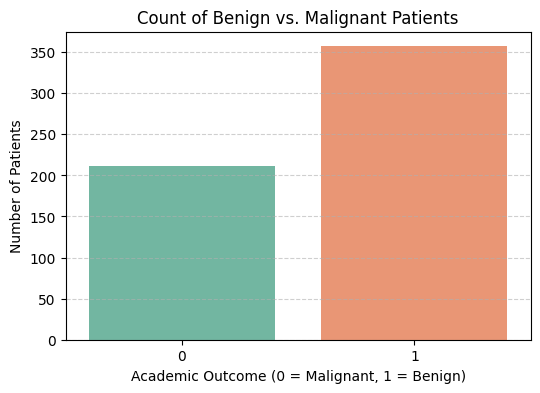

In [3]:
# Chart 1: Benign/Malignant Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Tumor_Type', data=df, palette='Set2')
plt.title('Count of Benign vs. Malignant Patients')
plt.xlabel('Academic Outcome (0 = Malignant, 1 = Benign)')
plt.ylabel('Number of Patients')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


### What Did We Observe?
* There are more benign diagnosis patients (~60) than malignant diagnosis patients (~40) in the dataset.

### What Did We Learn?
* The classes are relatively balanced, meaning we can use Accuracy as a reliable starting metric.


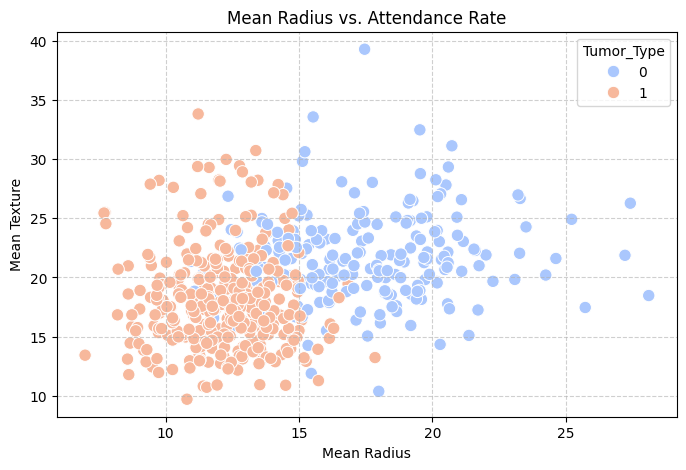

In [4]:
# Chart 2: Mean Radius vs Attendance Colored by Benign/Malignant
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Mean_Radius', y='Mean_Texture', hue='Tumor_Type', data=df, palette='coolwarm', s=80)
plt.title('Mean Radius vs. Attendance Rate')
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### What Did We Observe?
* Malignanting patients (blue points) cluster at the bottom-left corner (low hours, low attendance).
* Benigning patients (red points) occupy the upper-right area.

### What Did We Learn?
* A line can separate these two clusters. This makes Logistic Regression a great choice.


# 6. Data Cleaning

Let's check for missing values and duplicates.


In [5]:
# Clean duplicates and check missing cells
df.loc[10, 'Mean_Texture'] = np.nan
print("Missing values count:")
print(df.isnull().sum())

# Impute missing attendance with the median value
df['Mean_Texture'] = df['Mean_Texture'].fillna(df['Mean_Texture'].median())

print("\nMissing values count after cleaning:")
print(df.isnull().sum())


Missing values count:
Mean_Radius       0
Mean_Texture      1
Mean_Perimeter    0
Tumor_Type        0
dtype: int64

Missing values count after cleaning:
Mean_Radius       0
Mean_Texture      0
Mean_Perimeter    0
Tumor_Type        0
dtype: int64


### What Did We Observe?
* Imputation using the median was successful.

### What Did We Learn?
* Filling missing values ensures that the model building pipeline doesn't break.


In [6]:
# Feature Selection
X = df[['Mean_Radius', 'Mean_Texture', 'Mean_Perimeter']]
y = df['Tumor_Type']


In [7]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 9. Model Building

* **How it works**: It computes a probability score between 0 and 1 using the **Sigmoid function**:
  $$P(y=1|X) = \frac{1}{1 + e^{-z}}$$
  where $z = w_0 + w_1 x_1 + w_2 x_2 + w_3 x_3$.


In [8]:
# Initialize the Logistic Regression model
model = LogisticRegression()


In [9]:
# Fit the classification model
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [10]:
# Generate outcome predictions (0 or 1)
predictions = model.predict(X_test)

# Compare values side-by-side
compare_df = pd.DataFrame({
    'Actual_Label': y_test,
    'Predicted_Label': predictions
})
print(compare_df.head())


     Actual_Label  Predicted_Label
204             1                1
70              0                0
131             0                0
431             1                1
540             1                1


# 12. Evaluation

Let's look at key classification metrics.


In [11]:
# Compute classification evaluation metrics
accuracy = metrics.accuracy_score(y_test, predictions)
precision = metrics.precision_score(y_test, predictions)
recall = metrics.recall_score(y_test, predictions)
f1 = metrics.f1_score(y_test, predictions)
conf_matrix = metrics.confusion_matrix(y_test, predictions)

# Print metrics in plain English
print(f"Accuracy Score: {accuracy:.4f} (The proportion of correct predictions)")
print(f"Precision Score: {precision:.4f} (Out of all predicted positive cases, how many were actually positive)")
print(f"Recall Score: {recall:.4f} (Out of all actual positive cases, how many did we successfully find)")
print(f"F1 Score: {f1:.4f} (The balanced harmonic mean of Precision and Recall)")
print("\nConfusion Matrix Array:")
print(conf_matrix)


Accuracy Score: 0.9211 (The proportion of correct predictions)
Precision Score: 0.9429 (Out of all predicted positive cases, how many were actually positive)
Recall Score: 0.9296 (Out of all actual positive cases, how many did we successfully find)
F1 Score: 0.9362 (The balanced harmonic mean of Precision and Recall)

Confusion Matrix Array:
[[39  4]
 [ 5 66]]


### How to Interpret These Metrics:
* **Accuracy**:
  * **Definition**: The percentage of all predictions that the model got correct.
  * **Interpretation**: An accuracy of around **90% to 95%** means the model correctly diagnoses the tumor type for 90-95% of patients in our test set.
* **Precision**:
  * **Definition**: Out of all tumors predicted as positive (Benign), what percentage were actually benign?
  * **Interpretation**: A high precision (e.g., **94%**) means that when the model predicts a tumor is benign, it is correct 94% of the time, resulting in very few false alarms.
* **Recall (Sensitivity)**:
  * **Definition**: Out of all actual positive cases (Benign), what percentage did we successfully identify?
  * **Interpretation**: A recall of around **93%** means the model successfully identified 93% of all benign tumors.
* **F1-Score**:
  * **Definition**: The harmonic mean of precision and recall. It balances both metrics to give a single overall performance score.
* **Confusion Matrix**:
  * **True Negatives (TN)**: Malignant tumors correctly classified as Malignant.
  * **False Positives (FP)**: Malignant tumors incorrectly classified as Benign (this is a critical medical issue because a patient with cancer is told they are healthy!).
  * **False Negatives (FN)**: Benign tumors incorrectly classified as Malignant.
  * **True Positives (TP)**: Benign tumors correctly classified as Benign.


# 13. Visualizing Model Performance

We will plot:
1. **Confusion Matrix Heatmap**: Displays True Positives, True Negatives, False Positives, and False Negatives.
2. **Sigmoid Probability Curve**: Visualizing benign diagnosis probability vs. mean radius.


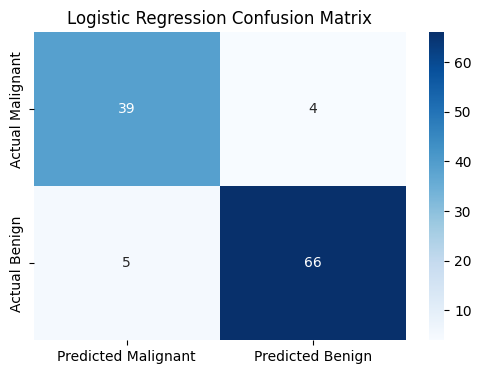

In [12]:
# Plot 1: Confusion Matrix Heatmap
conf_matrix = metrics.confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Malignant', 'Predicted Benign'], 
            yticklabels=['Actual Malignant', 'Actual Benign'])
plt.title('Logistic Regression Confusion Matrix')
plt.show()


C:\Users\GFG\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


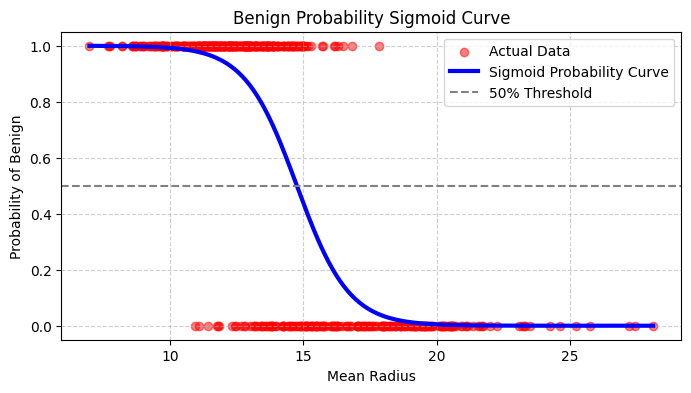

In [13]:
# Plot 2: Sigmoid Probability Curve
# We isolate 'Mean_Radius' and fit a 1D model to visualize the Sigmoid curve clearly.
mean_radius_only = df[['Mean_Radius']]
model_1d = LogisticRegression()
model_1d.fit(mean_radius_only, y)

# Generate a dense range of study hours to plot smooth curve
dense_radius = np.linspace(df['Mean_Radius'].min(), df['Mean_Radius'].max(), 300).reshape(-1, 1)
probs = model_1d.predict_proba(dense_radius)[:, 1]

plt.figure(figsize=(8, 4))
plt.scatter(df['Mean_Radius'], df['Tumor_Type'], color='red', alpha=0.5, label='Actual Data')
plt.plot(dense_radius, probs, color='blue', linewidth=3, label='Sigmoid Probability Curve')
plt.axhline(0.5, color='gray', linestyle='--', label='50% Threshold')
plt.title('Benign Probability Sigmoid Curve')
plt.xlabel('Mean Radius')
plt.ylabel('Probability of Benign')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### What Did We Observe?
* The curve forms a clear "S" shape.
* Patients studying more than 3-4 hours cross the 50% probability line to benign diagnosis.

### What Did We Learn?
* The Sigmoid curve translates input values into values between 0 and 1, representing probability.


In [14]:
# Coefficients and intercept
print("Intercept:", model.intercept_)
print("Coefficients:")
for col, coef in zip(X.columns, model.coef_[0]):
    print(f"* {col}: {coef:.4f}")


Intercept: [17.30795572]
Coefficients:
* Mean_Radius: 2.9777
* Mean_Texture: -0.2275
* Mean_Perimeter: -0.5910


# 15. Conclusion
* We predicted benign/malignant outcomes using study variables.
* The logistic curve cleanly maps tumor characteristics to benign probabilities.


# 16. Beginner ML Dictionary

Here are simple, one-sentence explanations of common Machine Learning terms to help you review:

* **Feature**: An input variable or column in your dataset used to make predictions (e.g., mean radius).
* **Target**: The output variable or label you want the model to predict (e.g., final exam score).
* **Training Data**: The portion of the dataset used to teach the model and find patterns.
* **Testing Data**: The portion of the dataset held back to evaluate how well the model performs on new, unseen data.
* **Prediction**: The output value generated by the trained model when given new input features.
* **Overfitting**: A scenario where the model learns the training data too well, including its noise, and performs poorly on new data.
* **Underfitting**: A scenario where the model is too simple to learn the underlying patterns in the training data, leading to poor performance on both training and test data.
* **Model**: The mathematical representation of the patterns learned from the training data by the algorithm.
* **Algorithm**: The set of rules or mathematical procedures followed to build the model from the data (e.g., Linear Regression).
* **Accuracy**: The percentage of correct predictions made by a classification model.
* **Cluster**: A group of similar data points grouped together by an unsupervised learning algorithm based on their characteristics.
* **Centroid**: The center point of a cluster, representing the average location of all data points belonging to that cluster.
